# Modelo de Admisión de Riesgo de Crédito Minorista
### Fase 1 - Comprensión de Cartera, Calidad del Dato y Análisis Exploratorio

---

**Autor:** Adrian Sabin Pelayo · Data Science | Riesgo de Crédito
**Ámbito:** Banca minorista - admisión y scoring de particulares

---

## Resumen ejecutivo

Toda entidad financiera que concede crédito se enfrenta a la misma tensión de negocio: **conceder financiación a la mayor cantidad de clientes solventes posible, evitando al mismo tiempo prestar a quienes no podrán devolver el dinero.** Un error en cualquiera de las dos direcciones tiene coste directo: aprobar a un mal pagador destruye capital, y rechazar a un buen cliente supone renunciar a ingresos y cuota de mercado.

Este proyecto aborda la **primera línea de defensa del banco frente a la morosidad**: un sistema capaz de estimar, en el momento de la solicitud, la probabilidad de que un cliente entre en mora grave (impago de 90 días o más) en los dos años siguientes.

Este primer cuaderno cubre las dos fases que sostienen la fiabilidad de cualquier modelo de riesgo posterior:

1. **Diagnóstico de la cartera** - entender el perfil de los clientes y cuánto pesa realmente la morosidad.
2. **Saneamiento del dato** - depurar errores de registro que, de no corregirse, distorsionarían las decisiones de concesión.

El resultado es una base de datos limpia y un conjunto de hallazgos de negocio que orientan la construcción del modelo de decisión.

> **Nota metodológica:** se trabaja con un conjunto de datos de referencia del sector (*Give Me Some Credit*), ampliamente utilizado para prototipar sistemas de admisión sin exponer información real de clientes.


## 1. Preparación del entorno de trabajo

Se cargan las librerías de análisis y se fija una identidad visual corporativa sobria (azul institucional y rojo de alerta) que se mantendrá en todos los gráficos del informe para facilitar su lectura.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paleta corporativa unificada para todo el informe
COLOR_PRINCIPAL = "#4A90D9"   # Azul institucional  -> clientes sanos / valores normales
COLOR_ALERTA    = "#E05C5C"   # Rojo de alerta      -> morosidad / riesgo
COLOR_NEUTRO    = "#7F8C99"   # Gris                -> elementos secundarios

sns.set_style("whitegrid")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 90

## 2. Carga de la cartera de clientes

Se incorpora la base de solicitantes. Cada fila representa un cliente y cada columna una característica financiera o de comportamiento observada en el momento de la solicitud.


In [4]:
df = pd.read_csv("data/cs-training.csv")
df = df.drop("Unnamed: 0", axis=1)   # Columna de índice sin valor de negocio

print(f"Cartera cargada: {df.shape[0]:,} clientes y {df.shape[1]} variables")
df.head(5)

Cartera cargada: 150,000 clientes y 11 variables


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 3. ¿Cuánto pesa la morosidad en la cartera?

Antes de construir cualquier modelo, la primera pregunta de negocio es sencilla: **¿qué proporción de clientes acaba impagando?** La respuesta condiciona toda la estrategia posterior, porque la morosidad es, por naturaleza, un evento poco frecuente.


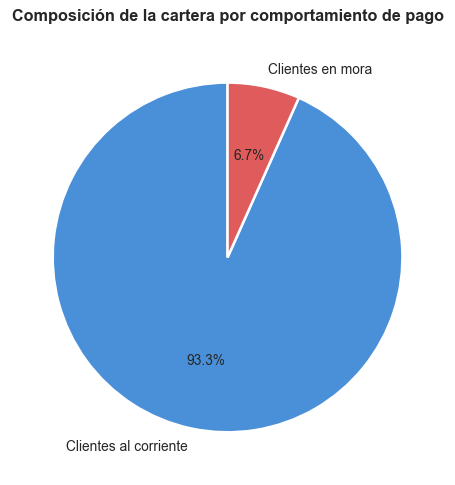

Clientes al corriente : 139,974 (93.3%)
Clientes en mora      : 10,026 (6.7%)


In [5]:
counts = df['SeriousDlqin2yrs'].value_counts()
tasa_morosidad = df['SeriousDlqin2yrs'].mean() * 100

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.pie(
    counts,
    autopct='%1.1f%%',
    labels=['Clientes al corriente', 'Clientes en mora'],
    colors=[COLOR_PRINCIPAL, COLOR_ALERTA],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
ax.set_title('Composición de la cartera por comportamiento de pago',
             fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print(f"Clientes al corriente : {counts[0]:,} ({100 - tasa_morosidad:.1f}%)")
print(f"Clientes en mora      : {counts[1]:,} ({tasa_morosidad:.1f}%)")

### Lectura de negocio

Solo **1 de cada 12 clientes** (aprox. 6,7%) entra en mora grave. Es una cartera sana en apariencia, pero este desequilibrio tiene una implicación crítica para el negocio:

- **La morosidad es un evento raro pero muy caro.** Cada impago no detectado puede destruir el margen generado por decenas de buenos clientes.
- **No basta con "acertar en la mayoría de los casos".** Un modelo que aprobara a todo el mundo acertaría el 93% de las veces y aun así sería inútil, porque su función es precisamente **identificar a esa minoría costosa.**

Este desequilibrio se tendrá en cuenta explícitamente en la fase de modelado, para que el sistema no ignore al cliente moroso por ser minoritario.


## 4. Diagnóstico de calidad del dato

Un modelo de riesgo es tan fiable como los datos que lo alimentan. Antes de sanear nada, se revisa la distribución de cada variable para detectar **errores de registro y valores imposibles** que, de colarse en el modelo, llevarían a decisiones de concesión equivocadas.


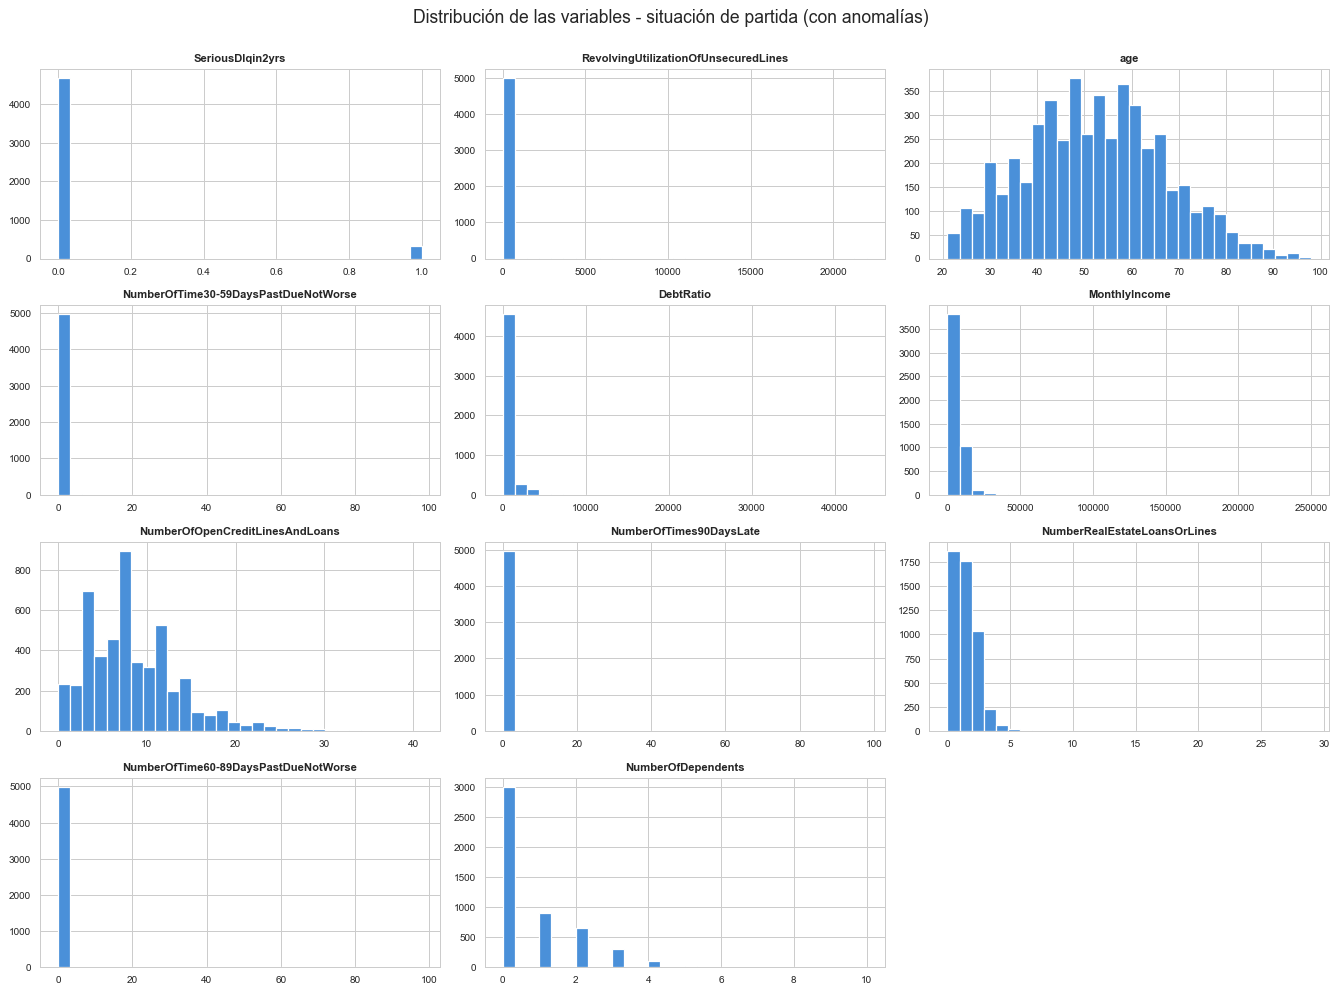

In [6]:
variables = df.columns

fig, axes = plt.subplots(4, 3, figsize=(15, 11))
axes = axes.flat

for i, feature in enumerate(variables):
    muestra = df[feature].dropna().sample(5000, random_state=42)
    axes[i].hist(muestra, bins=30, color=COLOR_PRINCIPAL, edgecolor="white")
    axes[i].set_title(feature, fontsize=9)
    axes[i].tick_params(labelsize=8)

axes[-1].set_visible(False)   # Ocultar la casilla sobrante (11 variables, 12 huecos)
fig.suptitle("Distribución de las variables - situación de partida (con anomalías)",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### Hallazgos: la cartera contiene errores de registro

La inspección revela varias anomalías que **no son riesgo real, sino defectos del dato** y que deben corregirse:

| Variable | Problema detectado | Interpretación de negocio |
|---|---|---|
| **Uso de crédito rotativo** | Valores por encima de 20.000 | Un cliente no puede usar 20.000 veces su límite; error claro |
| **Ratio de endeudamiento** | Valores hasta 40.000 | Un ratio de deuda sano ronda 0–1; estas cifras son imposibles |
| **Ingreso mensual** | Cola hasta 250.000 | Rentas extremas poco realistas que distorsionan la escala |
| **Historial de impagos** | Valores de 96–98 episodios | Códigos internos mal registrados, no morosidad real |

También se confirma que **la morosidad es un evento minoritario** y que la **edad** presenta una distribución razonable de clientes adultos.

**Conclusión:** la cartera necesita un saneamiento previo. Ignorar estos valores llevaría al modelo a "aprender" de información falsa.


## 5. Saneamiento de la cartera

Se aplican correcciones **conservadoras y justificadas**, buscando siempre preservar la información real del cliente y eliminar únicamente el ruido:

- **Edad:** se descartan registros por debajo de la mayoría de edad legal y con edades muy avanzadas(imposibles en concesión de crédito).
- **Historial de impagos y variables financieras extremas:** se limita el efecto de los valores atípicos al percentil 99, de modo que un puñado de registros erróneos no arrastre las decisiones del modelo (técnica estándar en banca).
- **Ratio de endeudamiento:** se acota a un máximo lógico, ya que valores de miles carecen de sentido financiero.


#### 5.1 Filtro de edad - solo mayores de edad

In [7]:
df = df[(df["age"] > 18) & (df["age"] < 90)] 
print(f"Cartera tras filtrar menores de edad: {df.shape[0]:,} clientes")

Cartera tras filtrar menores de edad: 149,312 clientes


#### 5.2 Control de valores extremos en variables financieras

In [8]:
# Historial de impagos: limitar valores atípicos al percentil 99
mora_vars = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate',
             'NumberOfTime60-89DaysPastDueNotWorse']

for var in mora_vars:
    p99 = df[var].quantile(0.99)
    df[var] = df[var].clip(upper=p99)

# Uso de crédito e ingresos: mismo criterio de percentil 99
ratio_vars = ['RevolvingUtilizationOfUnsecuredLines', 'MonthlyIncome']

for var in ratio_vars:
    p99 = df[var].quantile(0.99)
    df[var] = df[var].clip(upper=p99)

# Ratio de endeudamiento: tope lógico de negocio
df["DebtRatio"] = df["DebtRatio"].clip(upper=10)

#### 5.3 Revisión de información ausente

In [9]:
print(f"Dimensiones de la cartera: {df.shape[0]:,} clientes\n")
print("Datos ausentes por variable:")
print(df.isnull().sum())

Dimensiones de la cartera: 149,312 clientes

Datos ausentes por variable:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29413
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3803
dtype: int64


**Dos variables presentan huecos de información:**

- **Ingreso mensual** - es el campo más incompleto. Que un cliente no declare ingresos es habitual y, de hecho, en un modelo real la propia ausencia puede ser informativa.
- **Número de dependientes** - con pocos huecos, fácilmente subsanable.

Se completan ambos campos con el valor central (mediana) de cada variable, un criterio prudente que evita descartar clientes por un único dato faltante.


In [10]:
df["MonthlyIncome_missing"] = df["MonthlyIncome"].isna().astype(int)
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["NumberOfDependents"]  = df["NumberOfDependents"].fillna(df["NumberOfDependents"].median())

In [11]:
print(f"Dimensiones finales: {df.shape[0]:,} clientes")
print("\nComprobación de datos ausentes tras el saneamiento:")
print(df.isnull().sum())

Dimensiones finales: 149,312 clientes

Comprobación de datos ausentes tras el saneamiento:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MonthlyIncome_missing                   0
dtype: int64


## 6. La cartera después del saneamiento

Se repite la fotografía de las variables para verificar que las distribuciones ya son **coherentes con la realidad financiera**. Este es el dato que alimentará el modelo.


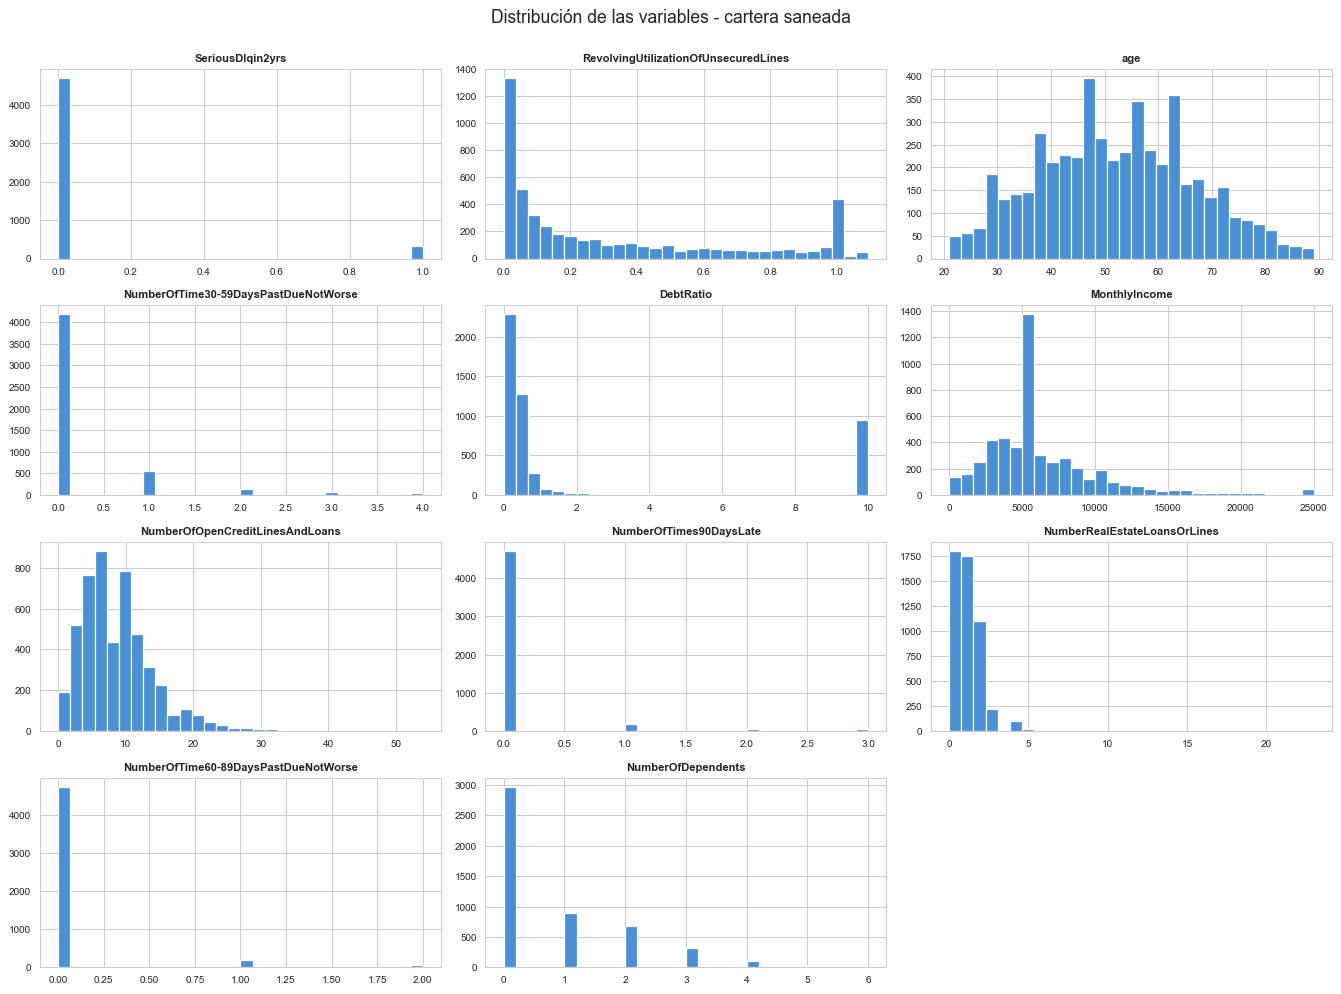

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(15, 11))
axes = axes.flat

for i, feature in enumerate(df.columns):
    muestra = df[feature].dropna().sample(5000, random_state=42)
    axes[i].hist(muestra, bins=30, color=COLOR_PRINCIPAL, edgecolor="white")
    axes[i].set_title(feature, fontsize=9)
    axes[i].tick_params(labelsize=8)

axes[-1].set_visible(False)
fig.suptitle("Distribución de las variables - cartera saneada",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### Perfil de la cartera saneada

Con el dato ya depurado, emerge el retrato del cliente tipo y de las señales de riesgo:

- **Historial de impagos** - la inmensa mayoría de clientes nunca ha tenido retrasos. Quienes sí los acumulan son minoría, pero serán los más relevantes para anticipar la morosidad.
- **Uso del crédito rotativo** - aparece un grupo de clientes que **agota su línea de crédito** (uso cercano al 100%), una señal clásica de tensión financiera.
- **Ratio de endeudamiento** - la mayoría muestra niveles bajos, indicativos de solvencia.
- **Ingreso mensual** - cartera de renta media, sin las distorsiones previas.
- **Edad** - cliente adulto consolidado (40–60 años), con historial crediticio establecido.

La cartera está lista para el análisis de relaciones entre variables.


## 7. ¿Qué señales anticipan la morosidad?

Se analiza cómo se relacionan las variables entre sí y, sobre todo, cuáles muestran mayor conexión con el impago. Este paso identifica las **palancas de riesgo** sobre las que se apoyará el modelo y detecta información redundante.


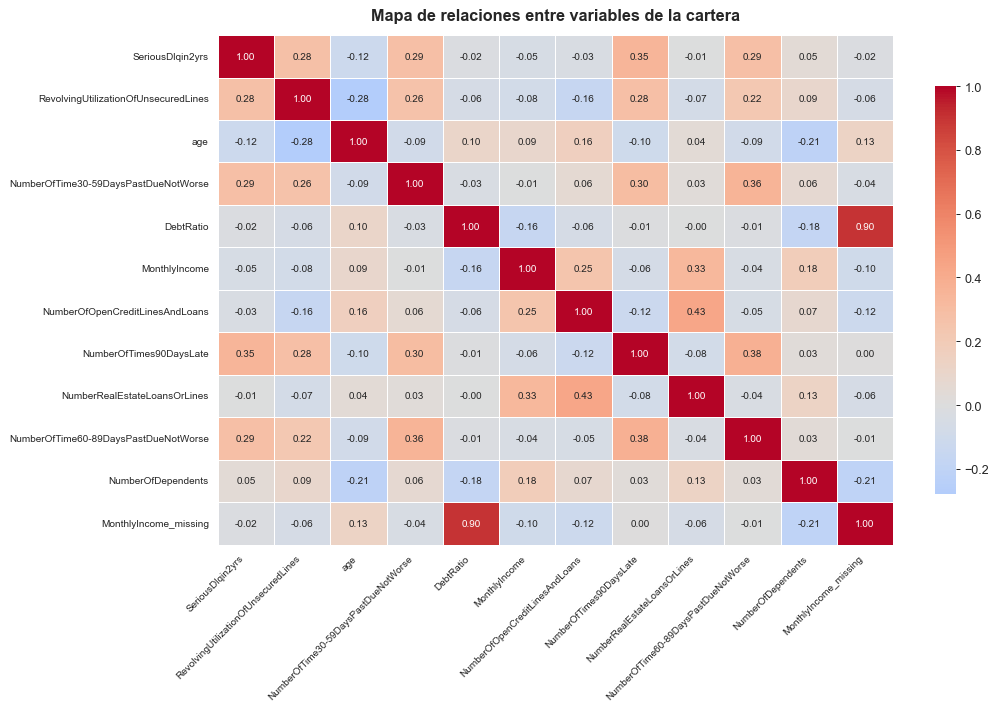

In [13]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", annot_kws={"size": 8},
    cmap="coolwarm", center=0,
    linewidths=0.5, square=False,
    cbar_kws={"shrink": 0.8}
)
plt.title("Mapa de relaciones entre variables de la cartera", fontsize=13, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Lectura de negocio

**Señales que más anticipan el impago:**
El historial de retrasos en el pago es, con diferencia, el mejor anticipador de la morosidad. Destaca el número de impagos graves de 90+ días (correlación de 0,35 con el impago), seguido de los retrasos de 30-59 y 60-89 días (0,29 cada uno). A ellos se suma el **uso del crédito rotativo** (0,28): los clientes que apuran su línea de crédito muestran mayor riesgo. La **edad** actúa en sentido inverso (-0,12): a mayor edad, menor probabilidad de impago.

**Las relaciones son moderadas:**
Ninguna variable por sí sola "predice" el impago de forma contundente. El riesgo de crédito es multifactorial: surge de la **combinación** de señales, no de una única causa. Por eso se necesita un modelo que integre todas las variables a la vez.

**Aviso detectado - información parcialmente redundante:**
Las tres variables de historial de impagos guardan relación entre sí (correlaciones de entre 0,30 y 0,38), lo cual es lógico: un cliente que se retrasa tiende a hacerlo en varios tramos. Aportan un mensaje solapado -"este cliente se retrasa"-, por lo que en el modelado convendrá vigilar esa redundancia y valorar consolidarlas en una única señal de comportamiento de pago, más clara y estable.

## 8. El retrato del cliente de alto riesgo

Se comparan directamente las distribuciones de los clientes que impagaron frente a los que no, sobre las variables más relevantes. Es la forma más visual de responder a la pregunta clave del negocio: **¿en qué se diferencia un buen cliente de un moroso?**


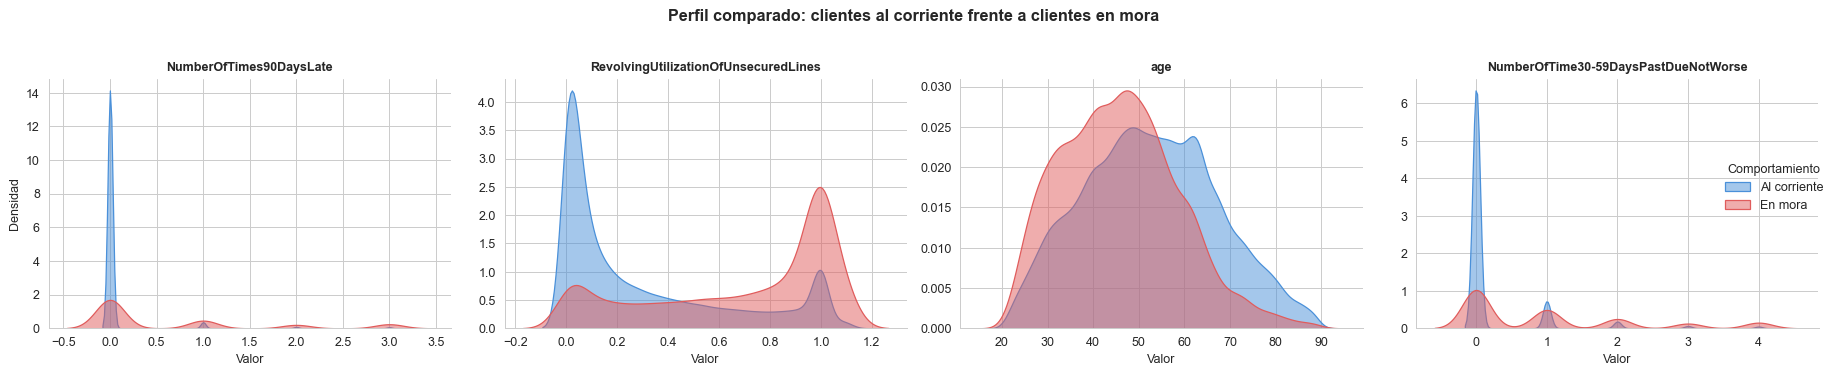

In [14]:
key_vars = ['NumberOfTimes90DaysLate', 'RevolvingUtilizationOfUnsecuredLines',
            'age', 'NumberOfTime30-59DaysPastDueNotWorse']

df_melted = df.melt(id_vars='SeriousDlqin2yrs', value_vars=key_vars)

g = sns.FacetGrid(
    df_melted, col="variable",
    hue="SeriousDlqin2yrs", palette=[COLOR_PRINCIPAL, COLOR_ALERTA],
    sharex=False, sharey=False, height=4, aspect=1.2
)
g.map(sns.kdeplot, "value", fill=True, alpha=0.5)
g.add_legend(title="Comportamiento", labels=["Al corriente", "En mora"])
g.set_titles(col_template="{col_name}", size=10)
g.set_axis_labels("Valor", "Densidad")
g.figure.suptitle("Perfil comparado: clientes al corriente frente a clientes en mora",
                   y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusión: quién es el cliente de riesgo

**Historial de impagos.** Los clientes en mora (rojo) presentan una cola clara hacia retrasos repetidos, mientras que los clientes sanos (azul) se concentran casi por completo en "cero retrasos". El mensaje de negocio es contundente: **cualquier episodio previo de mora, por leve que parezca, eleva de forma notable el riesgo futuro.** El comportamiento pasado de pago es el mejor anticipador del comportamiento futuro.

**Edad.** Es la diferencia más visible. Los clientes que impagan son **sistemáticamente más jóvenes**; a partir de los 60 años la probabilidad de mora cae de forma marcada. La juventud, asociada a menor estabilidad financiera y trayectoria crediticia más corta, es un factor de riesgo relevante.

> **Perfil del cliente de alto riesgo:** *joven y con algún episodio previo de retraso en el pago.* Este es el segmento sobre el que el banco debe afinar su política de admisión.


## 9. Conclusiones y recomendaciones accionables

### Qué se ha logrado en esta fase

1. **Diagnóstico de cartera.** La morosidad grave afecta a ~7% de los clientes: un evento minoritario pero de alto impacto económico, que exige un sistema de admisión afinado.
2. **Cartera saneada y fiable.** Se han corregido errores de registro (importes imposibles, edades no válidas, códigos de impago mal grabados) que habrían contaminado cualquier decisión de crédito.
3. **Identificación de las palancas de riesgo.** El comportamiento de pago histórico y la edad se perfilan como los principales anticipadores de la morosidad.

### Recomendaciones para el banco

| Recomendación | Justificación de negocio |
|---|---|
| **Priorizar el historial de pago en la admisión** | Es la señal más fiable de riesgo futuro; debe pesar en la decisión de concesión y en el precio del crédito |
| **Vigilancia reforzada del segmento joven** | Concentra la morosidad; conviene ajustar límites y condiciones, no necesariamente rechazar |
| **Monitorizar el uso del crédito rotativo** | El agotamiento de la línea es una alerta temprana de tensión financiera, útil también en seguimiento de clientes ya activos |
| **Institucionalizar el control de calidad del dato** | Los errores detectados serían invisibles en la operativa diaria pero degradan silenciosamente cualquier modelo de decisión |

### Próximo paso

Con la cartera saneada y las señales de riesgo identificadas, la siguiente fase construye el **modelo de decisión de admisión**: un sistema que combina todas estas variables para estimar, cliente a cliente, la probabilidad de impago y traducirla en una recomendación de concesión alineada con los objetivos de rentabilidad y control de riesgo del banco.


In [15]:
df.to_parquet("data/datos_limpios.parquet", index=False)
print("Cartera  guardada en datos_limpios.parquet")

Cartera  guardada en datos_limpios.parquet
